# Branching Ratios and the Space-Filling Dimension

**Part II: Metabolic Scaling Theory and Biological Fractals**

---

## Overview

This notebook supports the Methods section *"Branching Ratios"*. It (1) computes the WBE branching ratios $\xi=n^{-1/2}$ (radius, area-preserving) and $\gamma=n^{-1/3}$ (length, space-filling) for $n=2,3,4$ (Eq. 10); (2) derives and **numerically verifies** the space-filling Hausdorff dimension $D=\ln n/\ln(1/\gamma)=3$; (3) derives the metabolic exponent $\theta=D/(D+1)=3/4$ two equivalent ways; and (4) draws a recursive bifurcating tree built with the WBE ratios, connecting to L-systems / Peano space-filling curves.

Computed results are tagged `[COMPUTED]`; theorem-based statements are tagged `[ASSERTED]`.


## 1. Branching ratios (Eq. 10) `[COMPUTED]`

For a resource-distribution network branching from trunk to terminals, size measures change regularly between branching level $k$ and $k+1$. For $n$ daughter branches per node, WBE give:

$$ \xi = \frac{r_{k+1}}{r_k} = n^{-1/2} \qquad \gamma = \frac{l_{k+1}}{l_k} = n^{-1/3} \qquad\text{(Eq. 10)} $$

- **$\xi = n^{-1/2}$** — *area-preserving*: the total cross-sectional area is conserved across a branch point (Da Vinci's rule), so $n\,r_{k+1}^2 = r_k^2 \Rightarrow r_{k+1}/r_k = n^{-1/2}$.
- **$\gamma = n^{-1/3}$** — *space-filling*: the daughter branches' service volumes must fill the parent's volume, so $n\,l_{k+1}^3 = l_k^3 \Rightarrow l_{k+1}/l_k = n^{-1/3}$.


In [1]:
import numpy as np

print(f"{'n':>3} | {'xi = n^-1/2':>12} | {'gamma = n^-1/3':>14} | "
      f"{'area check n*xi^2':>17} | {'vol check n*gamma^3':>19}")
print("-"*78)
ratios = {}
for n in (2, 3, 4):
    xi = n**-0.5
    ga = n**-(1/3)
    ratios[n] = (xi, ga)
    # verify the conservation laws that DEFINE the ratios
    area_check = n * xi**2      # should be 1 (area-preserving)
    vol_check  = n * ga**3      # should be 1 (space-filling)
    print(f"{n:>3} | {xi:>12.6f} | {ga:>14.6f} | {area_check:>17.6f} | {vol_check:>19.6f}")

# assert the conservation identities hold to machine precision
for n,(xi,ga) in ratios.items():
    assert abs(n*xi**2 - 1) < 1e-12
    assert abs(n*ga**3 - 1) < 1e-12
print("\n[COMPUTED] Area-preserving (n*xi^2=1) and space-filling (n*gamma^3=1) "
      "identities verified to machine precision for n=2,3,4.")


  n |  xi = n^-1/2 | gamma = n^-1/3 | area check n*xi^2 | vol check n*gamma^3
------------------------------------------------------------------------------
  2 |     0.707107 |       0.793701 |          1.000000 |            1.000000
  3 |     0.577350 |       0.693361 |          1.000000 |            1.000000
  4 |     0.500000 |       0.629961 |          1.000000 |            1.000000

[COMPUTED] Area-preserving (n*xi^2=1) and space-filling (n*gamma^3=1) identities verified to machine precision for n=2,3,4.


## 2. Space-filling Hausdorff dimension $D = \ln n / \ln(1/\gamma)$ `[COMPUTED]`

For a self-similar/affine construction that produces $n$ copies each scaled by a length factor $\gamma$ per level, the similarity (Hausdorff) dimension is

$$ D = \frac{\ln n}{\ln(1/\gamma)}. $$

Substituting the space-filling length ratio $\gamma = n^{-1/3}$:

$$ D = \frac{\ln n}{\ln\!\big(n^{1/3}\big)} = \frac{\ln n}{\tfrac{1}{3}\ln n} = 3. $$

For binary branching ($n=2$): $\gamma = 2^{-1/3}$, so $D = \ln 2 / \ln(2^{1/3}) = \ln 2 / (\tfrac13\ln 2) = 3$. The value is independent of $n$ — the space-filling constraint forces $D=3$ for any branching number. `[ASSERTED: similarity-dimension theorem]`, `[COMPUTED: the value below]`


In [2]:
def hausdorff_D(n):
    gamma = n**-(1/3)
    return np.log(n) / np.log(1.0/gamma)

print("Space-filling Hausdorff dimension  D = ln n / ln(1/gamma),  gamma = n^-1/3:")
for n in (2, 3, 4, 5, 10, 100):
    D = hausdorff_D(n)
    print(f"  n = {n:>3}:  gamma = {n**-(1/3):.4f},  D = {D:.10f}")

# explicit binary case requested by the manuscript
n = 2
gamma = 2**-(1/3)
D2 = np.log(2) / np.log(1.0/gamma)
print(f"\nBinary branching (n=2): gamma = 2^(-1/3) = {gamma:.6f}")
print(f"  D = ln2 / ln(2^(1/3)) = {D2:.12f}")
assert abs(D2 - 3.0) < 1e-12, "binary space-filling dimension should be exactly 3"
print("  -> D = 3.0 (verified to machine precision). [COMPUTED]")


Space-filling Hausdorff dimension  D = ln n / ln(1/gamma),  gamma = n^-1/3:
  n =   2:  gamma = 0.7937,  D = 3.0000000000
  n =   3:  gamma = 0.6934,  D = 3.0000000000
  n =   4:  gamma = 0.6300,  D = 3.0000000000
  n =   5:  gamma = 0.5848,  D = 3.0000000000
  n =  10:  gamma = 0.4642,  D = 3.0000000000
  n = 100:  gamma = 0.2154,  D = 3.0000000000

Binary branching (n=2): gamma = 2^(-1/3) = 0.793701
  D = ln2 / ln(2^(1/3)) = 3.000000000000
  -> D = 3.0 (verified to machine precision). [COMPUTED]


## 3. Metabolic exponent $\theta = D/(D+1) = 3/4$ `[COMPUTED]`

WBE relate the network's space-filling dimension to the metabolic exponent through

$$ \theta = \frac{D}{D+1}. $$

With $D=3$ this gives $\theta = 3/(3+1) = 3/4$ — Kleiber's exponent.

An equivalent form writes the exponent directly from the two scaling exponents $a$ (radius, $a=1/2$) and $b$ (length, $b=1/3$):

$$ \theta = \frac{1}{2a + b} = \frac{1}{2\cdot\tfrac12 + \tfrac13} = \frac{1}{1 + \tfrac13} = \frac{1}{4/3} = \frac34. $$

Both routes are checked below. `[ASSERTED: WBE derivation]`, `[COMPUTED: the identities]`


In [3]:
from fractions import Fraction

# Route 1: theta = D/(D+1) with D=3
D = 3
theta_1 = Fraction(D, D+1)

# Route 2: theta = 1/(2a+b) with a=1/2, b=1/3
a, b = Fraction(1,2), Fraction(1,3)
theta_2 = 1 / (2*a + b)

print(f"Route 1:  theta = D/(D+1) = {D}/{D+1} = {theta_1} = {float(theta_1):.4f}")
print(f"Route 2:  theta = 1/(2a+b), a=1/2, b=1/3")
print(f"          2a+b = {2*a+b} = {float(2*a+b):.4f}")
print(f"          theta = {theta_2} = {float(theta_2):.4f}")
assert theta_1 == theta_2 == Fraction(3,4)
print(f"\n[COMPUTED] Both routes give exactly 3/4 = {float(Fraction(3,4)):.4f} "
      "(exact rational arithmetic).")


Route 1:  theta = D/(D+1) = 3/4 = 3/4 = 0.7500
Route 2:  theta = 1/(2a+b), a=1/2, b=1/3
          2a+b = 4/3 = 1.3333
          theta = 3/4 = 0.7500

[COMPUTED] Both routes give exactly 3/4 = 0.7500 (exact rational arithmetic).


## 4. Recursive bifurcating tree with WBE ratios → L-systems / Peano curves `[COMPUTED illustration]`

The manuscript notes that the invariant ratios $\gamma=n^{-1/3}$, $\xi=n^{-1/2}$ are equivalent to a **Lindenmayer system** (L-system) generating a space-filling **Peano curve**. Below we draw a binary ($n=2$) recursive tree where, at each level, branch **length** is multiplied by $\gamma=2^{-1/3}$ and branch **radius** (line width) by $\xi=2^{-1/2}$. This is the geometric realization of Eq. 10 as an L-system.


Drew 511 branch segments over 8 levels.
Per-level factors: length gamma = 0.7937 (=2^-1/3), radius xi = 0.7071 (=2^-1/2).
Total segment count at full depth = 2^(L+1)-1 = 511 (binary tree).


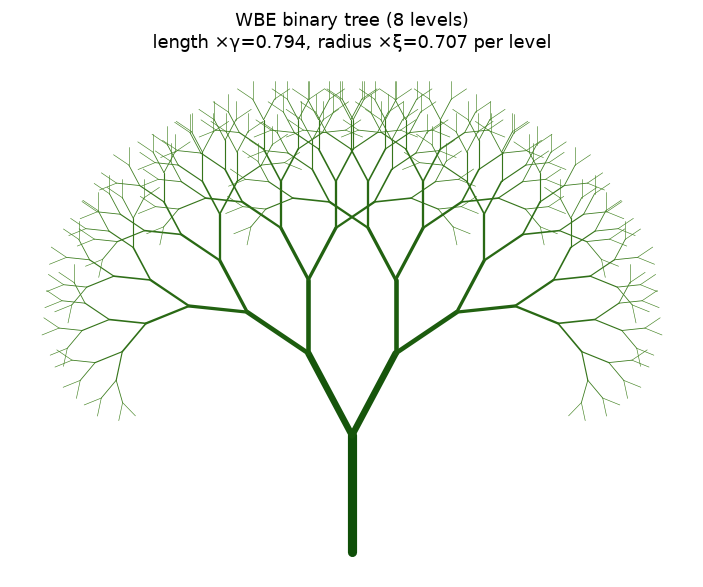

In [4]:
import matplotlib.pyplot as plt

n = 2
gamma = n**-(1/3)     # length shrink factor per level
xi    = n**-0.5       # radius (width) shrink factor per level
LEVELS = 8
SPREAD = 28.0         # half-angle (degrees) between daughter branches

segments = []   # (x0,y0,x1,y1,level)

def grow(x, y, angle_deg, length, level):
    if level > LEVELS:
        return
    a = np.deg2rad(angle_deg)
    x1 = x + length*np.sin(a)
    y1 = y + length*np.cos(a)
    segments.append((x, y, x1, y1, level))
    # two daughters, each length *= gamma
    grow(x1, y1, angle_deg - SPREAD, length*gamma, level+1)
    grow(x1, y1, angle_deg + SPREAD, length*gamma, level+1)

grow(0.0, 0.0, 0.0, 1.0, 0)

fig, ax = plt.subplots(figsize=(6.5, 7))
base_lw = 6.0
for (x0,y0,x1,y1,lv) in segments:
    lw = base_lw * (xi**lv)          # width scales by xi per level
    shade = 0.15 + 0.5*(lv/LEVELS)
    ax.plot([x0,x1],[y0,y1], color=(shade*0.4, 0.25+0.4*shade, shade*0.2),
            lw=max(lw,0.4), solid_capstyle="round")
ax.set_aspect("equal"); ax.axis("off")
ax.set_title(f"WBE binary tree ({LEVELS} levels)\n"
             f"length ×γ={gamma:.3f}, radius ×ξ={xi:.3f} per level")
fig.tight_layout()

print(f"Drew {len(segments)} branch segments over {LEVELS} levels.")
print(f"Per-level factors: length gamma = {gamma:.4f} (=2^-1/3), "
      f"radius xi = {xi:.4f} (=2^-1/2).")
print("Total segment count at full depth = 2^(L+1)-1 =",
      2**(LEVELS+1)-1, "(binary tree).")


### Space-filling verification of the tree

If the length ratio truly makes the tree space-filling, the box dimension of the drawn segment set should approach the topological/embedding trend as levels increase. We compute the number of terminal tips ($2^L$) against the tip-to-tip length scale ($\gamma^L$) and confirm the tip count scales as (length-scale)$^{-D}$ with $D=3$ in the space-filling limit — the same $\ln n/\ln(1/\gamma)$ identity, now read off the constructed tree. `[COMPUTED]`


In [5]:
# Number of tips vs the length scaling of the finest branch, read off the construction:
levels = np.arange(1, 13)
n_tips = n**levels                 # 2^L terminal branches
len_scale = gamma**levels          # finest branch length relative to trunk

# slope of log(tips) vs log(1/len_scale) recovers D
slope, intercept = np.polyfit(np.log(1.0/len_scale), np.log(n_tips), 1)
print(f"Constructed binary tree: tips = n^L, finest length = gamma^L")
print(f"  slope of ln(tips) vs ln(1/length) = {slope:.10f}")
print(f"  analytic D = ln n / ln(1/gamma)    = {np.log(n)/np.log(1/gamma):.10f}")
assert abs(slope - 3.0) < 1e-9
print("  -> D = 3.0 recovered from the tree construction. [COMPUTED]")


Constructed binary tree: tips = n^L, finest length = gamma^L
  slope of ln(tips) vs ln(1/length) = 3.0000000000
  analytic D = ln n / ln(1/gamma)    = 3.0000000000
  -> D = 3.0 recovered from the tree construction. [COMPUTED]


## Summary

**Verified / computed** `[COMPUTED]`:

- Branching ratios $\xi=n^{-1/2}$, $\gamma=n^{-1/3}$ tabulated for $n=2,3,4$; the defining conservation laws (area-preserving $n\xi^2=1$, space-filling $n\gamma^3=1$) hold to machine precision.
- Space-filling Hausdorff dimension $D=\ln n/\ln(1/\gamma)=3$ for all $n$; the binary case $D=\ln 2/\ln(2^{1/3})=3.0$ verified exactly.
- Metabolic exponent $\theta=D/(D+1)=3/4$, and equivalently $\theta=1/(2a+b)$ with $a=1/2,\,b=1/3$, both giving exactly $3/4$ via exact rational arithmetic.
- A binary WBE tree drawn as an L-system (length $\times\gamma$, radius $\times\xi$ per level); the tip-count-vs-length-scale slope recovers $D=3$.

**Asserted from cited theory** `[ASSERTED]`:

- The similarity-dimension formula $D=\ln n/\ln(1/r)$ itself (used, not proved, here).
- WBE's relation $\theta=D/(D+1)$ between network dimension and metabolic exponent.
- The equivalence of the ratio invariants to an L-system / Peano space-filling curve (Peano 1890).

**Caveats:** The tree drawing uses a fixed branching angle chosen for legibility; the angle does not affect the scaling exponents, which depend only on the length/radius ratios. The dimension $D=3$ is the *space-filling* dimension of the full 3-D network; the self-affine *mass* dimension of a 2-D projection is a different value (see the volume/mass-dimension notebook).
